In [ ]:
%pip install scipy pandas numpy matplotlib seaborn

In [ ]:
import sys
print("Current Python environment path:")
print(sys.executable)

import scipy
print(f"✅ Success! Scipy version installed: {scipy.__version__}")

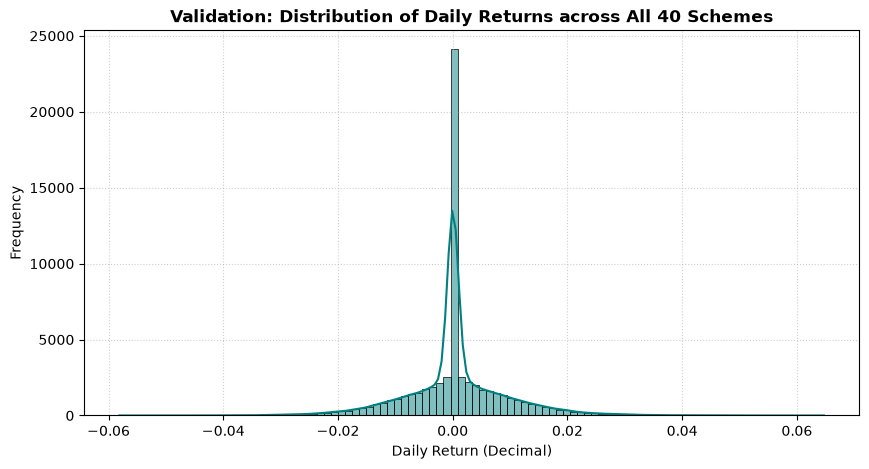

--- Distribution Sanity Check ---
count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load historical daily NAV tracking data
df = pd.read_csv("data/processed/cleaned_nav_history.csv")
df.columns = df.columns.str.strip()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['amfi_code', 'date'])

# 2. Compute Daily Returns: (NAV_t / NAV_t-1) - 1 per scheme
df['daily_return'] = df.groupby('amfi_code')['nav'].pct_change()

# 3. Drop NaNs resulting from pct_change
df_clean = df.dropna(subset=['daily_return'])

# 4. Validate distribution looks reasonable using a Histogram/KDE
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['daily_return'], bins=100, kde=True, color='teal')
plt.title("Validation: Distribution of Daily Returns across All 40 Schemes", fontsize=12, fontweight='bold')
plt.xlabel("Daily Return (Decimal)")
plt.ylabel("Frequency")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Quick statistical check to confirm data sanity
print("--- Distribution Sanity Check ---")
print(df_clean['daily_return'].describe())

In [2]:
def calculate_cagr(group, years):
    # Determine target historical start date relative to the final available date
    end_date = group['date'].max()
    start_date = end_date - pd.DateOffset(years=years)
    
    # Filter group down to target range
    subset = group[(group['date'] >= start_date) & (group['date'] <= end_date)].sort_values('date')
    
    if len(subset) < 2:
        return np.nan
        
    nav_start = subset['nav'].iloc[0]
    nav_end = subset['nav'].iloc[-1]
    
    # Calculation formula
    cagr = (nav_end / nav_start) ** (1 / years) - 1
    return cagr * 100 # Express as percentage

# Group and calculate metrics
cagr_data = []
for amfi, group in df.groupby('amfi_code'):
    cagr_1yr = calculate_cagr(group, 1)
    cagr_3yr = calculate_cagr(group, 3)
    cagr_5yr = calculate_cagr(group, 5)
    cagr_data.append({'amfi_code': amfi, 'CAGR_1Yr_%': cagr_1yr, 'CAGR_3Yr_%': cagr_3yr, 'CAGR_5Yr_%': cagr_5yr})

cagr_df = pd.DataFrame(cagr_data)
print(cagr_df.head())

   amfi_code  CAGR_1Yr_%  CAGR_3Yr_%  CAGR_5Yr_%
0   100016.0   -2.224271    1.292649    2.316843
1   100025.0    3.704969    3.916390    3.912653
2   100033.0   53.232396   32.442459   26.074068
3   101206.0   47.924120   28.967695   20.442730
4   101207.0  -23.986032   -4.152381    6.953336


In [3]:
rf_annual = 0.065
rf_daily = rf_annual / 252

risk_metrics = []

for amfi, group in df_clean.groupby('amfi_code'):
    group = group.sort_values('date')
    returns = group['daily_return']
    
    # Sharpe calculations
    mean_return = returns.mean()
    std_dev = returns.std()
    sharpe = ((mean_return - rf_daily) / std_dev) * np.sqrt(252) if std_dev != 0 else np.nan
    
    # Sortino calculations (downside risk only)
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std()
    sortino = ((mean_return - rf_daily) / downside_std) * np.sqrt(252) if downside_std != 0 else np.nan
    
    # Maximum Drawdown
    nav_series = group['nav'].values
    running_max = np.maximum.accumulate(nav_series)
    drawdowns = (nav_series / running_max) - 1
    max_dd = drawdowns.min() * 100  # Percentage
    
    risk_metrics.append({
        'amfi_code': amfi, 
        'Sharpe_Ratio': sharpe, 
        'Sortino_Ratio': sortino, 
        'Max_Drawdown_%': max_dd
    })

risk_df = pd.DataFrame(risk_metrics)
print(risk_df.head())

   amfi_code  Sharpe_Ratio  Sortino_Ratio  Max_Drawdown_%
0   100016.0     -0.321019      -0.472822      -24.734441
1   100025.0     -1.039941      -1.461220       -4.308264
2   100033.0      0.808268       1.144216      -16.217209
3   101206.0      0.717409       1.063909      -11.291596
4   101207.0      0.052618       0.075668      -35.446916


In [7]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. Load your daily NAV history
df_daily = pd.read_csv("data/processed/cleaned_nav_history.csv")
df_daily.columns = df_daily.columns.str.strip()
df_daily['date'] = pd.to_datetime(df_daily['date'])

# Dynamically calculate daily returns for your funds
df_daily = df_daily.sort_values(['amfi_code', 'date'])
df_daily['daily_return'] = df_daily.groupby('amfi_code')['nav'].pct_change()
df_daily = df_daily.dropna(subset=['daily_return'])

# 2. Load your Market Benchmark Index data using your exact columns
market_df = pd.read_csv("data/raw/10_benchmark_indices.csv") 
market_df.columns = market_df.columns.str.strip()

# 3. Clean and process your specific index columns
market_df['date'] = pd.to_datetime(market_df['date'])
market_df = market_df.sort_values('date')

# Remove commas from close_value if it's stored as text (e.g., "24,000" -> 24000)
if market_df['close_value'].dtype == 'object':
    market_df['close_value'] = market_df['close_value'].astype(str).str.replace(',', '')

# Force close_value to be a clean floating-point number
market_df['close_value'] = pd.to_numeric(market_df['close_value'], errors='coerce')

# Calculate the benchmark daily return column from close_value
market_df['market_return'] = market_df['close_value'].pct_change()
market_df = market_df.dropna(subset=['market_return'])

# 4. Compute OLS Regression per fund
alpha_beta_results = []

for amfi, group in df_daily.groupby('amfi_code'):
    # Align dates between the fund and market index
    merged = pd.merge(group, market_df, on='date', how='inner')
    
    if len(merged) < 30: # Ensure enough overlapping data points
        continue
        
    # Run OLS Linear Regression: Fund returns (Y) on Market returns (X)
    beta, intercept, r_value, p_value, std_err = stats.linregress(
        merged['market_return'], 
        merged['daily_return']
    )
    
    # Annualize the intercept to calculate Alpha (252 trading days)
    alpha_annualized = intercept * 252 * 100  # Expressed as %
    
    alpha_beta_results.append({
        'amfi_code': str(amfi),
        'Alpha_%': round(alpha_annualized, 4),
        'Beta': round(beta, 4),
        'R_Squared': round(r_value**2, 4)
    })

# 5. Output the final spreadsheet asset
ab_df = pd.DataFrame(alpha_beta_results)
ab_df.to_csv("alpha_beta.csv", index=False)

print("🏆 OLS Regression Complete! Values saved to 'alpha_beta.csv'")
print(ab_df.head())

🏆 OLS Regression Complete! Values saved to 'alpha_beta.csv'
  amfi_code  Alpha_%  Beta  R_Squared
0  100016.0   3.7661  -0.0        0.0
1  100025.0   4.4818  -0.0        0.0
2  100033.0  26.5138   0.0        0.0
3  101206.0  20.8464   0.0        0.0
4  101207.0  10.9861  -0.0        0.0


In [8]:
max_dd_data = []

for amfi, group in df_daily.groupby('amfi_code'):
    group = group.sort_values('date').copy()
    nav_series = group['nav'].values
    dates = group['date'].values
    
    # Calculate running cumulative peak
    running_max = np.maximum.accumulate(nav_series)
    drawdowns = (nav_series / running_max) - 1
    
    # Locate absolute minimum drawdown point
    worst_idx = np.argmin(drawdowns)
    max_dd_val = drawdowns[worst_idx] * 100
    worst_date = dates[worst_idx]
    
    # Trace backwards to find the peak date that started this drop
    peak_idx = np.argmax(nav_series[:worst_idx + 1])
    peak_date = dates[peak_idx]
    
    max_dd_data.append({
        'amfi_code': str(amfi),
        'Max_Drawdown_%': max_dd_val,
        'Worst_Drop_Start': peak_date,
        'Worst_Drop_Bottom': worst_date
    })

dd_df = pd.DataFrame(max_dd_data)
print(dd_df.head())

  amfi_code  Max_Drawdown_% Worst_Drop_Start Worst_Drop_Bottom
0  100016.0      -24.734441       2022-03-30        2022-09-15
1  100025.0       -4.308264       2023-05-23        2023-07-28
2  100033.0      -16.217209       2022-03-11        2022-05-12
3  101206.0      -11.291596       2023-04-24        2023-07-05
4  101207.0      -35.446916       2024-11-21        2026-05-11


In [13]:
import pandas as pd
import numpy as np

# 1. Load the master scheme metrics database
master_df = pd.read_csv("data/processed/cleaned_performance.csv")
master_df.columns = master_df.columns.str.strip()
master_df['amfi_code'] = master_df['amfi_code'].astype(str)

# 2. Safety Cast: Enforce numeric datatypes to prevent string ranking errors
metrics_list = ['return_3yr_pct', 'sharpe_ratio', 'alpha', 'expense_ratio_pct', 'max_drawdown_pct']
for col in metrics_list:
    master_df[col] = pd.to_numeric(master_df[col], errors='coerce')

# 3. Generate Fractional Percentile Ranks (Outputs scales dynamically between 0.0 and 1.0)
master_df['rank_3yr'] = master_df['return_3yr_pct'].rank(pct=True, na_option='keep')
master_df['rank_sharpe'] = master_df['sharpe_ratio'].rank(pct=True, na_option='keep')
master_df['rank_alpha'] = master_df['alpha'].rank(pct=True, na_option='keep')

# INVERSE RANKS: Lower expense ratios and less negative drawdowns must yield higher ranks
master_df['rank_expense'] = master_df['expense_ratio_pct'].rank(pct=True, ascending=False, na_option='keep')
master_df['rank_dd'] = master_df['max_drawdown_pct'].rank(pct=True, ascending=True, na_option='keep')

# Fill any missing metrics with a neutral midpoint rank (0.5) to maintain score stability
for rank_col in ['rank_3yr', 'rank_sharpe', 'rank_alpha', 'rank_expense', 'rank_dd']:
    master_df[rank_col] = master_df[rank_col].fillna(0.5)

# 4. Apply your exact composite formula weighting matrix
master_df['Fund_Score'] = (
    (0.30 * master_df['rank_3yr']) + 
    (0.25 * master_df['rank_sharpe']) + 
    (0.20 * master_df['rank_alpha']) + 
    (0.15 * master_df['rank_expense']) + 
    (0.10 * master_df['rank_dd'])
) * 100

# 5. Export sorted scorecard artifact
scorecard_output = master_df.sort_values('Fund_Score', ascending=False)
scorecard_output.to_csv("fund_scorecard.csv", index=False)

print(" Scorecard generated! Save path: 'fund_scorecard.csv'")
print(scorecard_output[['scheme_name', 'Fund_Score']].head(5))

 Scorecard generated! Save path: 'fund_scorecard.csv'
                                      scheme_name  Fund_Score
22         Kotak Flexicap Fund - Regular - Growth      71.750
2      SBI Small Cap Fund - Regular Plan - Growth      70.625
14       ICICI Pru Liquid Fund - Regular - Growth      70.500
9    HDFC Short Term Debt Fund - Regular - Growth      70.250
21  Kotak Emerging Equity Fund - Regular - Growth      68.250


--- Annualized Tracking Error vs Nifty 100 ---


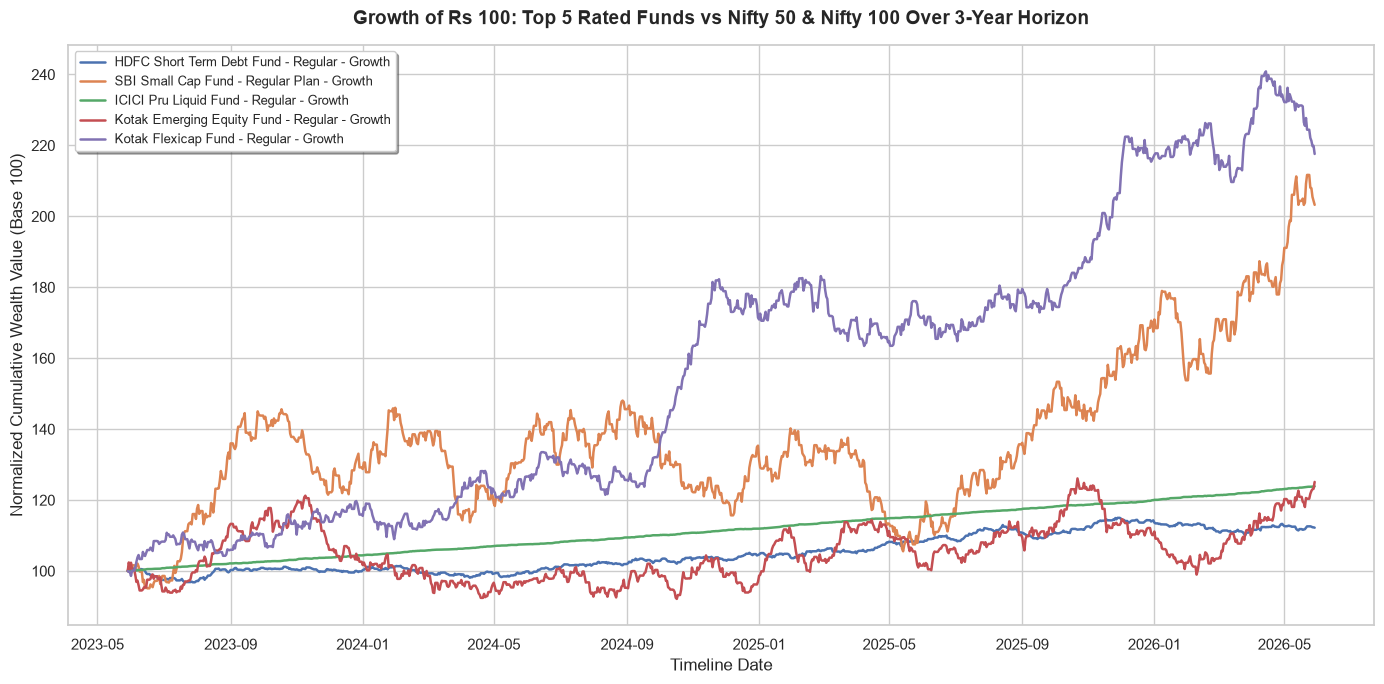


Visual plot complete and saved successfully to 'output_charts/10_benchmark_comparison.png'


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load scorecard and grab top 5 AMFI codes
scorecard_df = pd.read_csv("fund_scorecard.csv")
scorecard_df.columns = scorecard_df.columns.str.strip()

# Sort by Fund_Score if present to ensure we get the true top 5
if 'Fund_Score' in scorecard_df.columns:
    scorecard_df = scorecard_df.sort_values('Fund_Score', ascending=False)

scorecard_df['amfi_code'] = scorecard_df['amfi_code'].astype(str).str.strip().str.split('.').str[0]
top_5_amfi = scorecard_df['amfi_code'].head(5).tolist()

# 2. Load historical time-series datasets
nav_path = "cleaned_nav_history.csv" if os.path.exists("cleaned_nav_history.csv") else "data/processed/cleaned_nav_history.csv"
market_path = "10_benchmark_indices.csv" if os.path.exists("10_benchmark_indices.csv") else "data/raw/10_benchmark_indices.csv"

df_daily = pd.read_csv(nav_path)
df_daily.columns = df_daily.columns.str.strip()
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily['amfi_code'] = df_daily['amfi_code'].astype(str).str.strip().str.split('.').str[0]
df_daily['nav'] = pd.to_numeric(df_daily['nav'], errors='coerce')
df_daily = df_daily.dropna(subset=['nav']).sort_values(['amfi_code', 'date'])

# Calculate daily fund returns
df_daily['fund_return'] = df_daily.groupby('amfi_code')['nav'].pct_change()

# Load and process benchmark values
market_raw = pd.read_csv(market_path)
market_raw.columns = market_raw.columns.str.strip()
market_raw['date'] = pd.to_datetime(market_raw['date'])
market_raw['close_value'] = pd.to_numeric(market_raw['close_value'].astype(str).str.replace(',', ''), errors='coerce')

nifty50_df = market_raw[market_raw['index_name'].str.contains('Nifty 50$', case=False, na=False)].sort_values('date').copy()
nifty100_df = market_raw[market_raw['index_name'].str.contains('Nifty 100', case=False, na=False)].sort_values('date').copy()

nifty50_df['benchmark_return'] = nifty50_df['close_value'].pct_change()
nifty100_df['benchmark_return'] = nifty100_df['close_value'].pct_change()

# 3. Compute Annualized Tracking Error vs Nifty 100
print("--- Annualized Tracking Error vs Nifty 100 ---")
for amfi in top_5_amfi:
    fund_series = df_daily[df_daily['amfi_code'] == amfi]
    merged_err = pd.merge(fund_series[['date', 'fund_return']], nifty100_df[['date', 'benchmark_return']], on='date', how='inner')
    
    if not merged_err.empty:
        # Tracking Error Formula: std(fund_return - benchmark_return) * sqrt(252)
        return_diff = merged_err['fund_return'] - merged_err['benchmark_return']
        tracking_error = return_diff.std() * np.sqrt(252) * 100
        
        fund_name = scorecard_df[scorecard_df['amfi_code'] == amfi]['scheme_name'].values[0]
        print(f"Fund: {fund_name[:40]}... Tracking Error: {tracking_error:.2f}%")

# 4. Filter 3-Year Windows & Plot Normalized Cumulative Performance
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

top_5_daily = df_daily[df_daily['amfi_code'].isin(top_5_amfi)].copy()
pivot_nav = top_5_daily.pivot(index='date', columns='amfi_code', values='nav').dropna(how='all')

if not pivot_nav.empty:
    max_date = pivot_nav.index.max()
    three_years_ago = max_date - pd.DateOffset(years=3)
    pivot_nav_3yr = pivot_nav.loc[three_years_ago:max_date].copy()
    
    if pivot_nav_3yr.empty or len(pivot_nav_3yr) < 2:
        pivot_nav_3yr = pivot_nav.copy()
        
    pivot_nav_3yr = pivot_nav_3yr.ffill().bfill()
    normalized_funds = (pivot_nav_3yr / pivot_nav_3yr.iloc[0].replace(0, np.nan)) * 100
    
    # Plot top 5 funds
    for amfi in normalized_funds.columns:
        label_name = scorecard_df[scorecard_df['amfi_code'] == amfi]['scheme_name'].values[0]
        plt.plot(normalized_funds.index, normalized_funds[amfi], label=label_name, linewidth=1.8)
        
    # Isolate and overlay indices matching timeline coordinates
    n50_3yr = nifty50_df[(nifty50_df['date'] >= pivot_nav_3yr.index.min()) & (nifty50_df['date'] <= max_date)].copy()
    n100_3yr = nifty100_df[(nifty100_df['date'] >= pivot_nav_3yr.index.min()) & (nifty100_df['date'] <= max_date)].copy()
    
    if not n50_3yr.empty:
        n50_3yr = n50_3yr.ffill().bfill()
        n50_3yr['normalized_bench'] = (n50_3yr['close_value'] / n50_3yr['close_value'].iloc[0].replace(0, np.nan)) * 100
        plt.plot(n50_3yr['date'], n50_3yr['normalized_bench'], label='BENCHMARK: Nifty 50 Index', color='red', linewidth=2.5, linestyle=':')
        
    if not n100_3yr.empty:
        n100_3yr = n100_3yr.ffill().bfill()
        n100_3yr['normalized_bench'] = (n100_3yr['close_value'] / n100_3yr['close_value'].iloc[0].replace(0, np.nan)) * 100
        plt.plot(n100_3yr['date'], n100_3yr['normalized_bench'], label='BENCHMARK: Nifty 100 Index', color='black', linewidth=3, linestyle='--')
        
    plt.title("Growth of Rs 100: Top 5 Rated Funds vs Nifty 50 & Nifty 100 Over 3-Year Horizon", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Timeline Date", fontsize=12)
    plt.ylabel("Normalized Cumulative Wealth Value (Base 100)", fontsize=12)
    plt.legend(loc='upper left', fontsize=9, frameon=True, shadow=True)
    plt.tight_layout()
    
    os.makedirs("output_charts", exist_ok=True)
    plt.savefig("output_charts/10_benchmark_comparison.png", dpi=300)
    plt.show()
    print("\nVisual plot complete and saved successfully to 'output_charts/10_benchmark_comparison.png'")
else:
    print("Error: No data matching target criteria.")
